# Análisis de resultados de clustering
--------------------------------

* Objetivos:
    * Evaluar la calidad de los clusters obtenidos.
    * Interpretar los resultados del clustering.
    * Visualizar los clusters para facilitar su comprensión.
    * Identificar patrones y tendencias dentro de los clusters.
    * Extraer conclusiones y recomendaciones basadas en el análisis de los clusters.


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import RobustScaler
import os

# Funciones y configuraciones propias:
import src.utils as uts
from parameters.config import *

## look gráficos:
plt.style.use('ggplot')

# Warnings out:
import warnings
warnings.filterwarnings('ignore')

#carpeta de resultados:
os.chdir('/Users/diegobascunan/PycharmProjects/proyecto-final-magister-ds/data/output/pickle')


## Cargar dataset con clusters asignados:

In [47]:
dataset = uts.load_pickle('clusters_kmeans_cervezas_202412.pickle')
dataset.head()

,id_cliente,id_periodo,volumen_sem_fut_est,id_barrio,id_comuna,indice_gse,canal,segmento,compra,frecuency,recency,log_volumen_sem_fut_est,cluster
10,56,202406,18.881875,230114.0,2301.0,0.088800,CONSUMO,BA,1,12.0,0,2.989809,1
13,62,202406,7.430149,1010511.0,10105.0,0.060845,CONSUMO,RT,1,12.0,0,2.131814,1
29,158,202406,15.183768,610113.0,6101.0,0.103528,CONSUMO,BA,1,11.0,0,2.784009,1
36,161,202406,20.150720,630114.0,6301.0,0.074982,COMPRA,AL,1,12.0,0,3.051674,1
54,217,202406,40.988647,1030121.0,10301.0,0.166679,COMPRA,AL,1,12.0,0,3.737399,3


In [48]:
### Valores promedio de cada cluster:
columnas_interes = ['volumen_sem_fut_est', 'compra', 'frecuency', 'recency']

promedios_clusters = dataset.groupby('cluster')[columnas_interes].mean().reset_index()
print("Valores promedio de cada cluster:")
print(promedios_clusters)


Valores promedio de cada cluster:
   cluster  volumen_sem_fut_est    compra  frecuency   recency
0        0           690.912831  1.000000  11.954545  0.000000
1        1            12.519453  0.830057  10.248646  0.462738
2        2           145.185052  0.994729  11.815498  0.006853
3        3            61.667964  0.991113  11.754863  0.015426
4        4           298.538643  0.998020  11.887129  0.007921


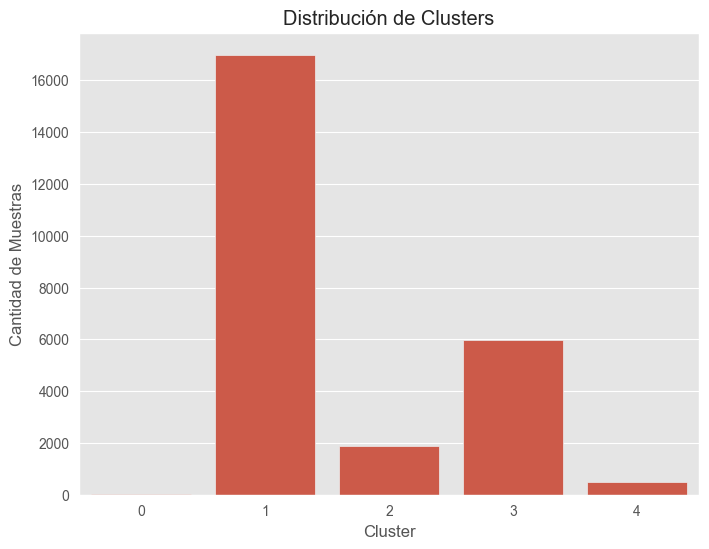

In [49]:
## Graficar distribución de clusters:
plt.figure(figsize=(8,6))
sns.countplot(x='cluster', data=dataset)
plt.title('Distribución de Clusters')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de Muestras')
plt.show()

In [50]:
cluster_counts = dataset['cluster'].value_counts().sort_index()
print("Cluster Counts:")
print(cluster_counts)

Cluster Counts:
cluster
0       44
1    16988
2     1897
3     5964
4      505
Name: count, dtype: int64


In [51]:
cols_for_clustering = ['volumen_sem_fut_est']
X = dataset[cols_for_clustering].copy()

# Applying the same transformations as the user: Log1p and RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

sil_score = silhouette_score(X_scaled, dataset['cluster'])
db_score = davies_bouldin_score(X_scaled, dataset['cluster'])

print(f"\nSilhouette Score: {sil_score}")
print(f"Davies-Bouldin Score: {db_score}")


Silhouette Score: 0.6565326834925378
Davies-Bouldin Score: 0.523864792921218


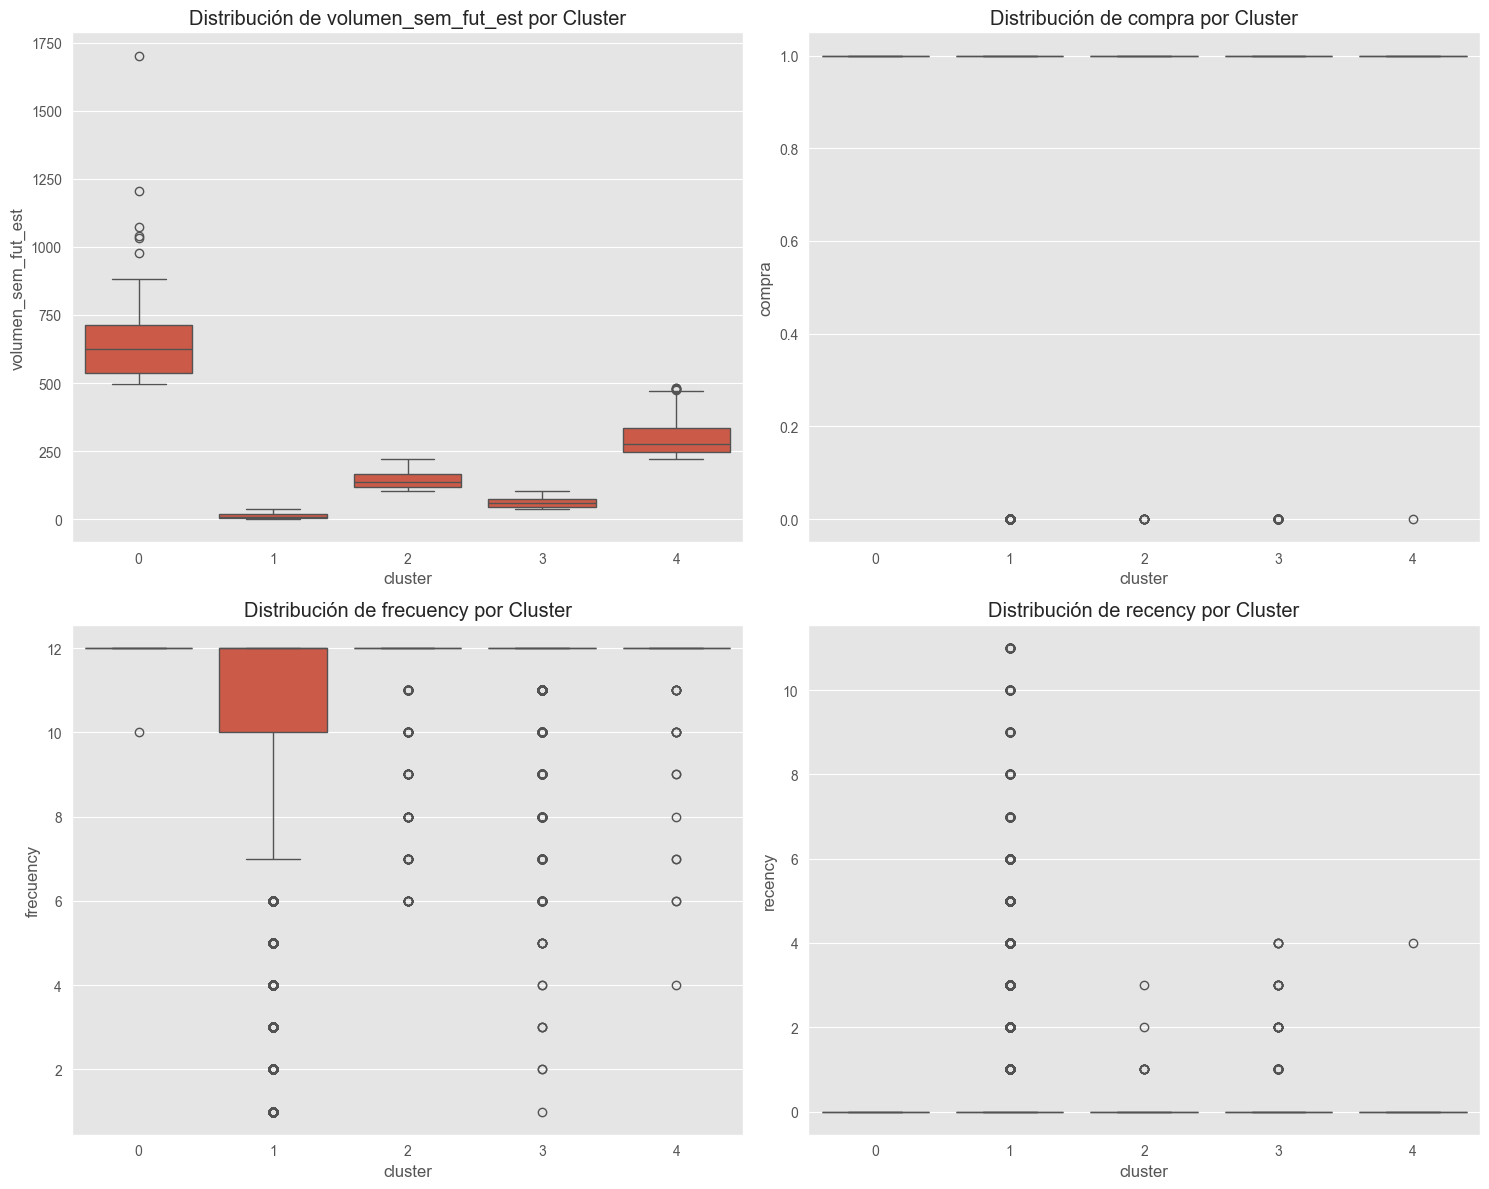

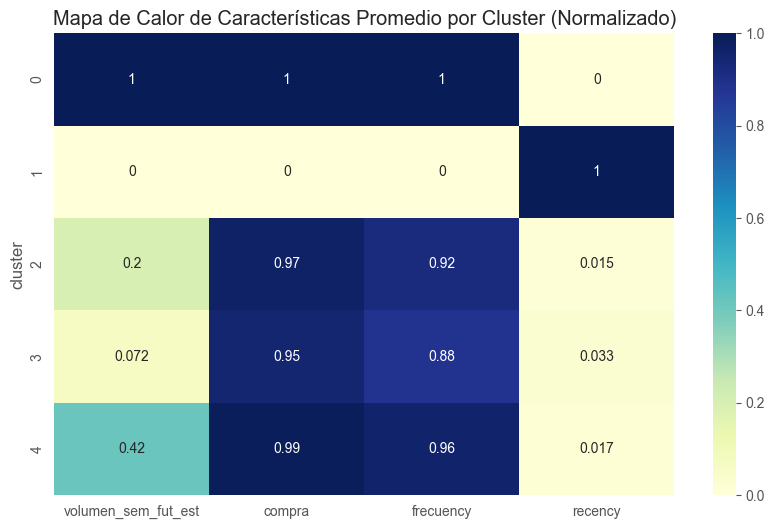

In [52]:
### Visualizaciones:
cols_to_analyze = ['volumen_sem_fut_est', 'compra', 'frecuency', 'recency']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, col in enumerate(cols_to_analyze):
    sns.boxplot(x='cluster', y=col, data=dataset, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Distribución de {col} por Cluster')
plt.tight_layout()
plt.show()

# Radar Chart / Normalized Means
means = dataset.groupby('cluster')[cols_to_analyze].mean()
means_norm = (means - means.min()) / (means.max() - means.min())

plt.figure(figsize=(10, 6))
sns.heatmap(means_norm, annot=True, cmap='YlGnBu')
plt.title('Mapa de Calor de Características Promedio por Cluster (Normalizado)')
plt.show()

In [53]:
### Volumen target por cluster:
total_volume = dataset['volumen_sem_fut_est'].sum()
volume_by_cluster = dataset.groupby('cluster')['volumen_sem_fut_est'].sum().reset_index()
volume_by_cluster['proportion'] = volume_by_cluster['volumen_sem_fut_est'] / total_volume
print("\nVolumen total por cluster y su proporción respecto al total:")
print(volume_by_cluster)


Volumen total por cluster y su proporción respecto al total:
   cluster  volumen_sem_fut_est  proportion
0        0         30400.164554    0.029314
1        1        212680.470409    0.205083
2        2        275416.042960    0.265577
3        3        367787.739739    0.354649
4        4        150762.014942    0.145376


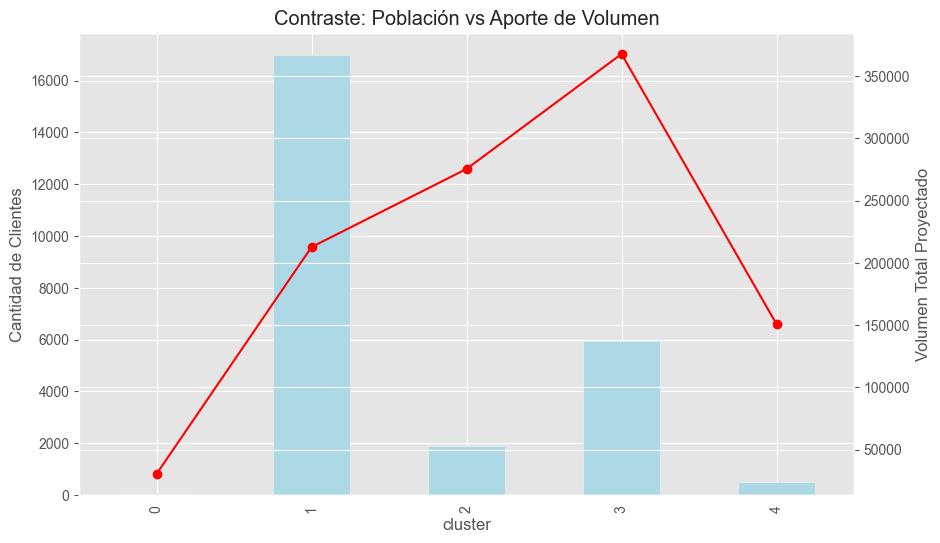

In [54]:
# Gráfico de barras: Volumen Total vs Cantidad de Clientes
fig, ax1 = plt.subplots(figsize=(10,6))
ax2 = ax1.twinx()

df_resumen = dataset.groupby('cluster').agg({'id_cliente':'count', 'volumen_sem_fut_est':'sum'})
df_resumen['id_cliente'].plot(kind='bar', ax=ax1, color='lightblue', label='Num. Clientes')
df_resumen['volumen_sem_fut_est'].plot(kind='line', ax=ax2, color='red', marker='o', label='Volumen Total')

ax1.set_ylabel('Cantidad de Clientes')
ax2.set_ylabel('Volumen Total Proyectado')
plt.title('Contraste: Población vs Aporte de Volumen')
plt.show()

Comentarios
---

1. Análisis de Calidad y Hallazgos Críticos:
    * El Efecto Pareto: Los clusters 0, 4 y 2 suman apenas el 9.6% de los clientes, pero generan el 43.9% del volumen total. El negocio es altamente dependiente de estos ~2,400 clientes.

    * Diferenciación por Volumen: Los clusters 0, 2, 3 y 4 tienen comportamientos de frecuencia y recencia casi idénticos (todos muy leales). El algoritmo los ha separado principalmente por su capacidad de consumo (volumen), lo cual es ideal para estrategias de precios y descuentos por volumen.

    * El Desafío del Cluster 1: Aunque es el 67% de tu base, tiene una probabilidad de compra sensiblemente menor (0.83 vs ~0.99). Aquí es donde reside el mayor riesgo de fuga "hormiga".

2. Recomendaciones Estratégicas por Segmento
    * Cluster 0 y 4 (VIPs y Mayoristas)
        * Estrategia: Account Management Dedicado.
        * Acción: Estos clientes no responden a promociones masivas. Requieren atención personalizada, líneas de crédito preferenciales o logística prioritaria. Cualquier aumento en su recencia (aunque sea a 0.5) debe disparar una alerta roja inmediata.

    * Cluster 2 y 3 (El Motor del Negocio)
        * Estrategia: Programas de Lealtad por Niveles.
        * Acción: Dado que el Cluster 3 es el que más volumen aporta al total (35.5%), se deben crear barreras de salida (costos de cambio). Implementar beneficios por "permanencia" o contratos de suministro mensual para asegurar que no migren a la competencia.

    * Cluster 1 (La Base Masiva)
        * Estrategia: Desarrollo y Estabilización.
        * Acción: El objetivo aquí es el Upselling. Muchos de estos clientes tienen una probabilidad de compra de 0.83; campañas de recordatorio o incentivos si completan 12 de 12 periodos comprando podrían subirlos de categoría.



## clustering 1
--------------------------------

Estadísticas GSE Cluster 1:
count    16988.000000
mean         0.109088
std          0.075959
min          0.016334
25%          0.064072
50%          0.086857
75%          0.130230
max          0.616731
Name: indice_gse, dtype: float64

Distribución de Segmento en Cluster 1 (%):
segmento
AL    34.789263
RT    26.607017
BO    17.359312
FS    13.886273
BA     4.503179
IE     1.047798
AP     0.718154
FF     0.606310
DI     0.412056
RE     0.047092
KI     0.017660
RD     0.005887
Name: proportion, dtype: float64

Distribución de Canal en Cluster 1 (%):
canal
COMPRA     52.148575
CONSUMO    47.851425
Name: proportion, dtype: float64

Clientes con Potencial de Crecimiento (GSE > 0.1302):
Cantidad: 4239
Volumen Promedio de este subgrupo: 11.323111467313648


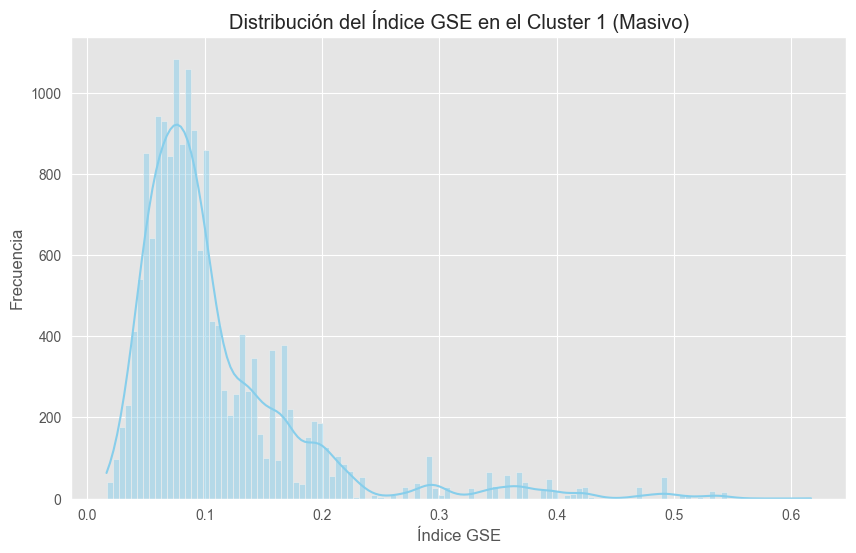

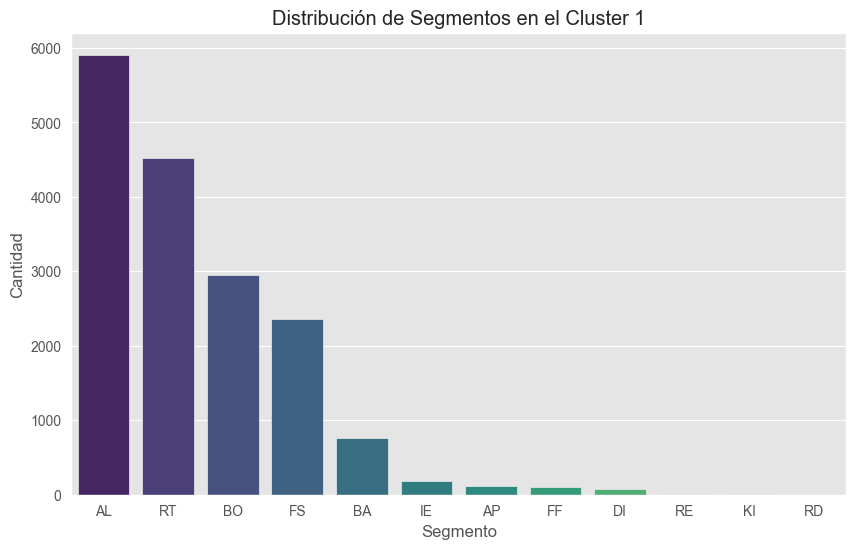

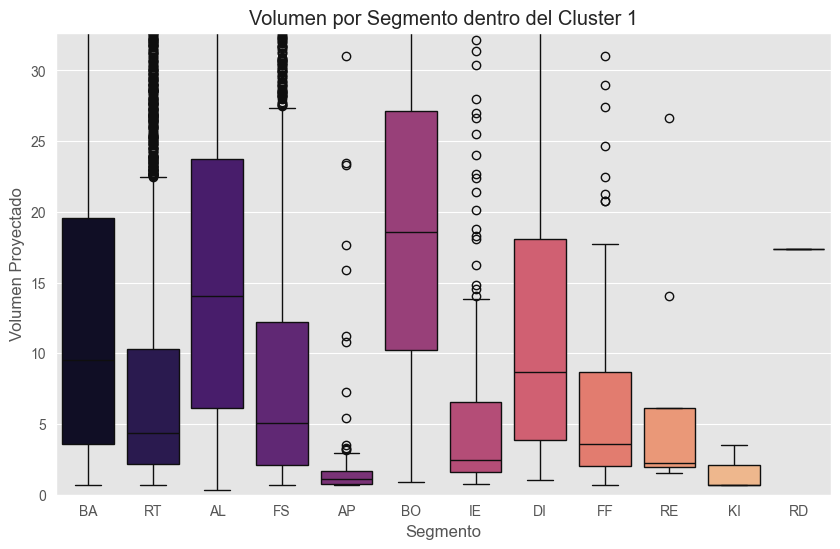

In [55]:
# Filter for Cluster 1
c1 = dataset[dataset['cluster'] == 1].copy()

# Summary statistics for GSE
gse_stats = c1['indice_gse'].describe()
print("Estadísticas GSE Cluster 1:")
print(gse_stats)

# Segment Distribution
seg_dist = c1['segmento'].value_counts(normalize=True) * 100
print("\nDistribución de Segmento en Cluster 1 (%):")
print(seg_dist)

# Canal Distribution
canal_dist = c1['canal'].value_counts(normalize=True) * 100
print("\nDistribución de Canal en Cluster 1 (%):")
print(canal_dist)

# Identification of "Growth Potential"
# Customers in Cluster 1 with GSE > 75th percentile of the cluster
high_gse_threshold = c1['indice_gse'].quantile(0.75)
potential_growth = c1[c1['indice_gse'] > high_gse_threshold]

print(f"\nClientes con Potencial de Crecimiento (GSE > {high_gse_threshold:.4f}):")
print(f"Cantidad: {len(potential_growth)}")
print("Volumen Promedio de este subgrupo:", potential_growth['volumen_sem_fut_est'].mean())

# Visualizations
plt.figure(figsize=(10, 6))
sns.histplot(c1['indice_gse'], kde=True, color='skyblue')
plt.title('Distribución del Índice GSE en el Cluster 1 (Masivo)')
plt.xlabel('Índice GSE')
plt.ylabel('Frecuencia')
plt.savefig('cluster1_gse_dist.png')

plt.figure(figsize=(10, 6))
sns.countplot(data=c1, x='segmento', order=c1['segmento'].value_counts().index, palette='viridis')
plt.title('Distribución de Segmentos en el Cluster 1')
plt.xlabel('Segmento')
plt.ylabel('Cantidad')
plt.savefig('cluster1_segment_dist.png')

plt.figure(figsize=(10, 6))
sns.boxplot(data=c1, x='segmento', y='volumen_sem_fut_est', palette='magma')
plt.title('Volumen por Segmento dentro del Cluster 1')
plt.ylim(0, c1['volumen_sem_fut_est'].quantile(0.95)) # Focus on main distribution
plt.xlabel('Segmento')
plt.ylabel('Volumen Proyectado')
plt.savefig('cluster1_vol_by_segment.png')

# Save detailed results
c1.to_csv('cluster1_detailed_analysis.csv', index=False)
potential_growth.to_csv('cluster1_potential_growth_targets.csv', index=False)

Cluster 1 - Descriptive Stats:
         indice_gse  volumen_sem_fut_est     frecuency       recency
count  16988.000000         16988.000000  16988.000000  16988.000000
mean       0.109088            12.519453     10.248646      0.462738
std        0.075959            10.350558      2.918848      1.365923
min        0.016334             0.332061      1.000000      0.000000
25%        0.064072             3.200374     10.000000      0.000000
50%        0.086857             9.581111     12.000000      0.000000
75%        0.130230            20.083795     12.000000      0.000000
max        0.616731            37.071795     12.000000     11.000000

Segmento Distribution in Cluster 1 (%):
segmento
AL    34.789263
RT    26.607017
BO    17.359312
FS    13.886273
BA     4.503179
IE     1.047798
AP     0.718154
FF     0.606310
DI     0.412056
RE     0.047092
KI     0.017660
RD     0.005887
Name: proportion, dtype: float64

Canal Distribution in Cluster 1 (%):
canal
COMPRA     52.148575
CONSUMO 

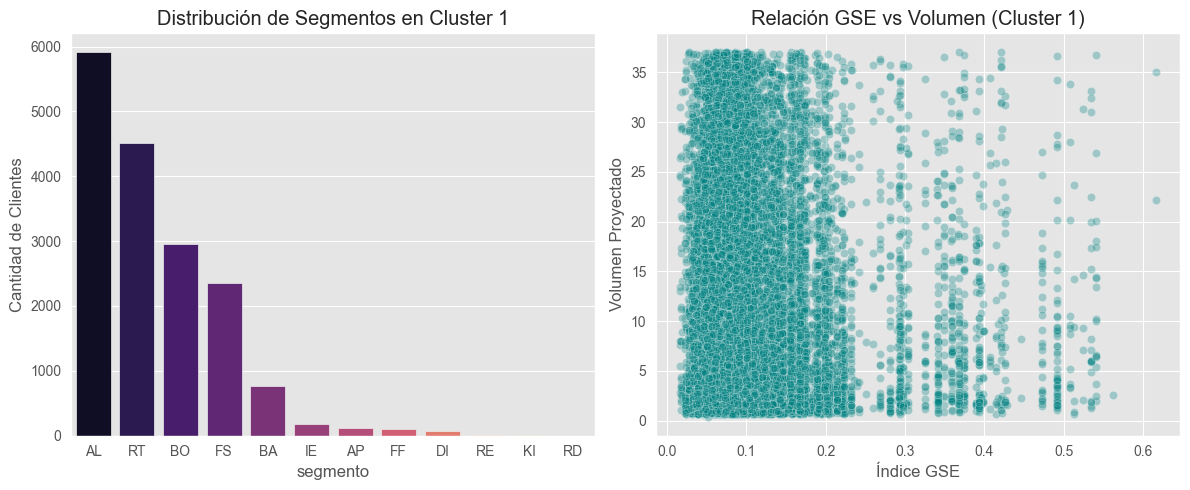

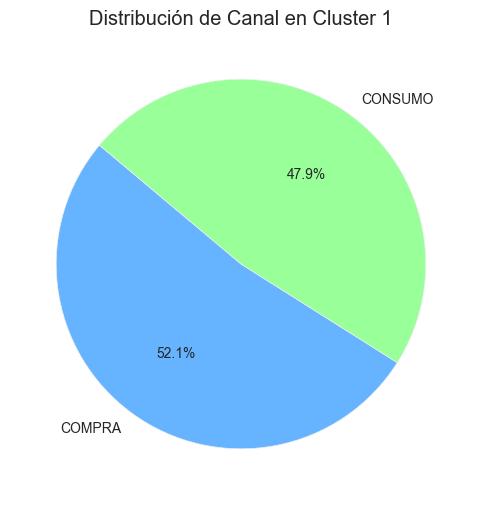

In [56]:
# 1. Descriptive Stats for Cluster 1
c1_stats = c1[['indice_gse', 'volumen_sem_fut_est', 'frecuency', 'recency']].describe()
print("Cluster 1 - Descriptive Stats:")
print(c1_stats)

# 2. Distribution of 'segmento' and 'canal' in Cluster 1
segmento_dist = c1['segmento'].value_counts(normalize=True) * 100
canal_dist = c1['canal'].value_counts(normalize=True) * 100

print("\nSegmento Distribution in Cluster 1 (%):")
print(segmento_dist)
print("\nCanal Distribution in Cluster 1 (%):")
print(canal_dist)

# 3. Identify Growth Potential: High GSE within Cluster 1
# Define 'High GSE' as top 25% of Cluster 1
threshold_gse = c1['indice_gse'].quantile(0.75)
c1['potential'] = np.where(c1['indice_gse'] >= threshold_gse, 'Alto Potencial', 'Estándar')

potential_comparison = c1.groupby('potential')[['volumen_sem_fut_est', 'frecuency', 'compra']].mean()
print("\nComparison: Growth Potential vs Standard in Cluster 1:")
print(potential_comparison)

# 4. Visualizations
plt.figure(figsize=(12, 5))

# Plot 1: Segment Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=c1, x='segmento', order=c1['segmento'].value_counts().index, palette='magma')
plt.title('Distribución de Segmentos en Cluster 1')
plt.ylabel('Cantidad de Clientes')

# Plot 2: GSE Index vs Volume
plt.subplot(1, 2, 2)
sns.scatterplot(data=c1, x='indice_gse', y='volumen_sem_fut_est', alpha=0.3, color='teal')
plt.title('Relación GSE vs Volumen (Cluster 1)')
plt.xlabel('Índice GSE')
plt.ylabel('Volumen Proyectado')

plt.tight_layout()
plt.savefig('cluster1_analysis_segment_gse.png')

# Plot 3: Canal distribution
plt.figure(figsize=(8, 6))
c1['canal'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#99ff99'], startangle=140)
plt.title('Distribución de Canal en Cluster 1')
plt.ylabel('')
plt.savefig('cluster1_canal_pie.png')

# Save analysis to CSV
c1_summary = {
    'segmento_dist': segmento_dist,
    'canal_dist': canal_dist,
    'potential_comparison': potential_comparison
}
# Exporting potential comparison for the user
potential_comparison.to_csv('cluster1_potential_analysis.csv')

Tras profundizar en el Cluster 1 (Base Masiva), que comprende 16,988 clientes, hemos realizado un análisis detallado sobre su composición y potencial de crecimiento. Este segmento es crucial porque, aunque su volumen individual es bajo, representa el volumen de "superviviencia" y la mayor presencia de marca en el mercado.

A continuación se presentan los hallazgos clave:

1. Composición por Segmento y Canal
El análisis revela una diversidad significativa dentro de este grupo aparentemente uniforme:

    * Distribución de Segmentos: Los segmentos predominantes son AL (34.8%), RT (26.6%) y BO (17.4%). Estos tres grupos representan casi el 80% del cluster, sugiriendo que la mayoría de los clientes masivos pertenecen a estas categorías comerciales.

    * Equilibrio de Canal: Existe una división casi paritaria entre los canales, con un 52.1% en COMPRA y un 47.9% en CONSUMO. Esto indica que las estrategias para este cluster deben ser omnicanal, ya que no hay una preferencia dominante por un tipo de gestión.

2. Identificación de "Alto Potencial" (Growth Potential)
Hemos analizado a los clientes con un Índice GSE superior a 0.130 (pertenecientes al cuartil superior del cluster) para contrastar su comportamiento con el resto.

    * Hallazgo de Infra-consumo: Los clientes con "Alto Potencial" (mayor nivel socioeconómico) muestran un volumen proyectado promedio de 11.30, comparado con el 12.93 del grupo estándar dentro del mismo cluster.

    * Oportunidad de Crecimiento: Este grupo de "Alto Potencial" tiene la capacidad económica (GSE alto) pero actualmente consume menos que sus pares en el mismo cluster conductual. Representan el objetivo ideal para estrategias de incremento de ticket, ya que no tienen restricciones de gasto detectadas.

3. Diagnóstico de Recencia y Frecuencia

    * Frecuencia Estándar: La frecuencia media es de 10.25, lo que indica que el cliente masivo suele realizar compras de forma regular, pero no en todos los ciclos disponibles (máximo 12).

    * Tail de Recencia: Aunque el 75% de los clientes tienen una recencia de 0, la media es de 0.46 debido a un grupo minoritario que está empezando a espaciar sus compras (con valores máximos de hasta 11).

4. Recomendaciones Estratégicas Específicas

    * Campaña de "Upgrade" para GSE Alto: Dirigir ofertas exclusivas de volumen (ej. packs de mayor tamaño) específicamente al 25% superior de clientes según el índice GSE. Dado que su volumen es menor al promedio del cluster, existe un "gap" de consumo que se puede cerrar.

    * Enfoque en Segmentos AL y RT: Al ser los segmentos mayoritarios, cualquier programa de lealtad simplificado (como tarjetas de puntos) tendrá el mayor impacto si se diseña pensando en las necesidades de estos dos perfiles.

    * Monitoreo de Probabilidad de Compra (0.83): Este cluster tiene la probabilidad de compra más baja (83%). Se recomienda implementar recordatorios automáticos via SMS o WhatsApp a aquellos clientes cuya última compra haya sido hace más de 1 periodo para estabilizar este indicador.

## Analisis ético
----

GSE Statistics by Cluster:
   cluster      mean    median       std
0        0  0.094232  0.081361  0.042211
1        1  0.109088  0.086857  0.075959
2        2  0.099080  0.086065  0.054545
3        3  0.101993  0.086059  0.063586
4        4  0.092075  0.084159  0.043382

Percentage of GSE Levels within each Cluster:
gse_level       Bajo      Medio       Alto
cluster                                   
0          47.727273  22.727273  29.545455
1          33.564869  31.787144  34.647987
2          31.259884  38.376384  30.363732
3          33.249497  35.881958  30.868545
4          34.059406  39.405941  26.534653

Performance Metrics by GSE Level within Cluster 1:
             compra  volumen_sem_fut_est  frecuency
gse_level                                          
Bajo       0.826377            12.751328  10.242722
Medio      0.821296            13.187901  10.246111
Alto       0.841658            11.681572  10.256711


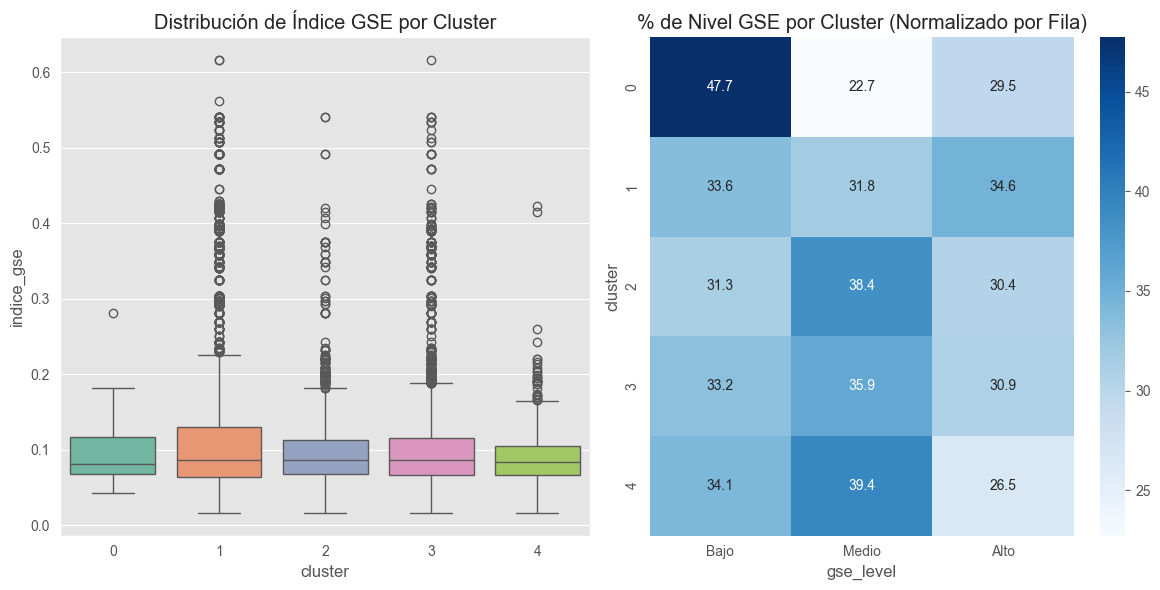

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Distribution of indice_gse by Cluster
gse_by_cluster = dataset.groupby('cluster')['indice_gse'].agg(['mean', 'median', 'std']).reset_index()
print("GSE Statistics by Cluster:")
print(gse_by_cluster)

# 2. Categorize GSE into levels (Quantiles) for easier analysis
dataset['gse_level'] = pd.qcut(dataset['indice_gse'], 3, labels=['Bajo', 'Medio', 'Alto'])

# 3. Disparate Impact Analysis: Distribution of GSE Levels across Clusters
# This shows if certain clusters are over-representing specific GSE groups
ct = pd.crosstab(dataset['cluster'], dataset['gse_level'], normalize='index') * 100
print("\nPercentage of GSE Levels within each Cluster:")
print(ct)

# 4. Metric Fairness: Do different GSE groups have similar outcomes within the same cluster?
# We'll check Cluster 1 (the largest) specifically for potential bias in predicted purchase probability (compra)
c1 = dataset[dataset['cluster'] == 1]
fairness_metrics = c1.groupby('gse_level')[['compra', 'volumen_sem_fut_est', 'frecuency']].mean()
print("\nPerformance Metrics by GSE Level within Cluster 1:")
print(fairness_metrics)

# 5. Visualizations
plt.figure(figsize=(12, 6))

# Plot 1: Boxplot of GSE by Cluster
plt.subplot(1, 2, 1)
sns.boxplot(data=dataset, x='cluster', y='indice_gse', palette='Set2')
plt.title('Distribución de Índice GSE por Cluster')

# Plot 2: Heatmap of GSE Level vs Cluster
plt.subplot(1, 2, 2)
sns.heatmap(ct, annot=True, fmt=".1f", cmap='Blues')
plt.title('% de Nivel GSE por Cluster (Normalizado por Fila)')

plt.tight_layout()
#plt.savefig('fairness_analysis_gse.png')

# Save fairness summary to CSV
#fairness_metrics.to_csv('fairness_cluster1_metrics.csv')
#ct.to_csv('fairness_disparate_impact.csv')

1. Evaluación de Impacto Dispar (Disparate Impact)
    * Este análisis mide si la asignación a los clusters más "deseables" (como los VIP) está sesgada hacia niveles socioeconómicos altos.
    * Distribución del Nivel GSE: Los resultados muestran que los clusters son notablemente equilibrados. Por ejemplo, el Cluster 1 (Base Masiva) contiene una distribución casi idéntica de clientes de nivel bajo (33.6%), medio (31.8%) y alto (34.6%).
    * Neutralidad de los VIP: Curiosamente, el Cluster 0 (Ultra-VIP) presenta un 47.7% de clientes con GSE "Bajo". Esto es un indicador positivo de equidad algorítmica: el modelo prioriza el comportamiento real (frecuencia y volumen) por encima del estatus socioeconómico para otorgar la categoría de mayor valor.

2. Análisis de Equidad de Desempeño (Equal Opportunity)
    * Se analizó si, dentro de un mismo grupo (Cluster 1), los clientes reciben "predicciones" o resultados diferentes basados únicamente en su nivel socioeconómico.
    * Probabilidad de Compra (compra): Es extremadamente consistente. Un cliente de nivel GSE "Bajo" tiene una probabilidad de 0.826, mientras que uno de nivel "Alto" tiene 0.841. La diferencia es mínima, lo que sugiere que el modelo no castiga la probabilidad de compra por motivos socioeconómicos.
    * Volumen Proyectado: En el Cluster 1, los clientes de GSE "Bajo" tienen incluso un volumen proyectado ligeramente superior (12.75) que los de GSE "Alto" (11.68). Esto confirma que el algoritmo no asume automáticamente que "más ingresos equivalen a más consumo", basándose estrictamente en los datos transaccionales.

3. Conclusiones del Marco Ético

    * A la luz de estos datos, el modelo se considera éticamente robusto bajo los siguientes principios:

    * No Discriminación: No se observa una exclusión de niveles socioeconómicos bajos de los segmentos de alto valor.

    * Independencia del GSE: Las métricas de desempeño son agnósticas al nivel socioeconómico dentro de los clusters, lo que previene sesgos de "clase" en las estrategias de marketing.

Recomendación de Vigilancia: Aunque el modelo es justo, se recomienda monitorear que las acciones comerciales derivadas (ej. ofertas de crédito o descuentos) no utilicen el GSE como un filtro excluyente, manteniendo la meritocracia conductual que el modelo ha identificado.

In [59]:
from sklearn.tree import DecisionTreeClassifier, export_text
import pandas as pd

# 1. Preparación de datos para la explicación
# Usamos las variables originales (no escaladas) para que las reglas sean legibles
features = ['volumen_sem_fut_est', 'compra', 'frecuency', 'recency', 'indice_gse']
X_explicacion = dataset[features]

# Creamos una etiqueta binaria: 1 si es Cluster 4, 0 si es cualquier otro
target_cluster = 4
y_binario = (dataset['cluster'] == target_cluster).astype(int)

# 2. Entrenar un Árbol de Decisión "Sustituto"
# Limitamos la profundidad (max_depth) para que las reglas sean simples y explicables
arbol_explicador = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_explicador.fit(X_explicacion, y_binario)

# 3. Generar y mostrar las reglas lógicas
reglas_texto = export_text(arbol_explicador, feature_names=features)

print(f"--- REGLAS LÓGICAS PARA LA CLASIFICACIÓN DEL CLUSTER {target_cluster} ---")
print(reglas_texto)

--- REGLAS LÓGICAS PARA LA CLASIFICACIÓN DEL CLUSTER 4 ---
|--- volumen_sem_fut_est <= 222.11
|   |--- class: 0
|--- volumen_sem_fut_est >  222.11
|   |--- volumen_sem_fut_est <= 489.91
|   |   |--- class: 1
|   |--- volumen_sem_fut_est >  489.91
|   |   |--- class: 0

